# Sales Performance Analysis

## Project Overview

This project analyzes sales data to understand overall business performance, sales and profit trends, product and category performance, regional performance, customer segments, shipping modes, discounts, and other key business metrics.

The analysis was performed using Python and Pandas, with visualizations created using Matplotlib.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("C:\\Users\\Medhya Khatri\\OneDrive\\Desktop\\Internship Project\\Superstore Dataset.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [4]:
df.shape

(10194, 21)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [6]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [9]:
df['Order Date'].dtype

dtype('<M8[ns]')

In [10]:
print("Start Date:", df['Order Date'].min())
print("End Date:", df['Order Date'].max())

Start Date: 2023-01-03 00:00:00
End Date: 2026-12-30 00:00:00


In [11]:
print("Rows and Columns:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Rows and Columns: (10194, 21)
Missing Values: 0
Duplicate Rows: 0


In [12]:
print("Categories:")
print(df['Category'].unique())

print("\nSub-Categories:")
print(df['Sub-Category'].unique())

print("\nRegions:")
print(df['Region'].unique())

print("\nSegments:")
print(df['Segment'].unique())

print("\nShip Modes:")
print(df['Ship Mode'].unique())

Categories:
['Office Supplies' 'Furniture' 'Technology']

Sub-Categories:
['Paper' 'Binders' 'Labels' 'Storage' 'Art' 'Chairs' 'Fasteners' 'Phones'
 'Furnishings' 'Accessories' 'Bookcases' 'Envelopes' 'Appliances' 'Tables'
 'Supplies' 'Machines' 'Copiers']

Regions:
['Central' 'East' 'South' 'West']

Segments:
['Consumer' 'Home Office' 'Corporate']

Ship Modes:
['Standard Class' 'First Class' 'Second Class' 'Same Day']


In [13]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,228.225854,3.791838,0.155385,28.673417
std,619.906839,2.228317,0.206249,232.465115
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.220000,2.000000,0.000000,1.760800
50%,53.910000,3.000000,0.200000,8.690000
75%,209.500000,5.000000,0.200000,29.297925
max,22638.480000,14.000000,0.800000,8399.976000


In [14]:
df['Year'] = df['Order Date'].dt.year

In [15]:
df['Month'] = df['Order Date'].dt.month

In [16]:
df['Month Name'] = df['Order Date'].dt.month_name()

In [17]:
df['Quarter'] = df['Order Date'].dt.quarter

In [18]:
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

In [19]:
df[['Order Date', 'Year', 'Month', 'Month Name', 'Quarter', 'Sales', 'Profit', 'Profit Margin']].head()

,Order Date,Year,Month,Month Name,Quarter,Sales,Profit,Profit Margin
0,2023-01-03,2023,1,January,1,16.448,5.5512,33.75
1,2023-01-04,2023,1,January,1,3.540,-5.4870,-155.00
2,2023-01-04,2023,1,January,1,11.784,4.2717,36.25
3,2023-01-04,2023,1,January,1,272.736,-64.7748,-23.75
4,2023-01-05,2023,1,January,1,19.536,4.8840,25.00


In [20]:
df[['Year', 'Month', 'Quarter', 'Profit Margin']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           10194 non-null  int32  
 1   Month          10194 non-null  int32  
 2   Quarter        10194 non-null  int32  
 3   Profit Margin  10194 non-null  float64
dtypes: float64(1), int32(3)
memory usage: 199.2 KB


In [21]:
df['Profit Margin'].describe()

count    10194.000000
mean        12.221784
std         46.488992
min       -275.000000
25%          7.500000
50%         27.000000
75%         36.250000
max         50.000000
Name: Profit Margin, dtype: float64

In [22]:
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 2326534.3543


In [23]:
total_profit = df['Profit'].sum()
print("Total Profit:", total_profit)

Total Profit: 292296.8146


In [24]:
total_orders = df['Order ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 5111


In [25]:
total_quantity = df['Quantity'].sum()
print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 38654


In [26]:
overall_profit_margin = (total_profit / total_sales) * 100
print("Overall Profit Margin:", overall_profit_margin)

Overall Profit Margin: 12.563614805849078


In [27]:
monthly_sales = df.groupby(
    ['Year', 'Month', 'Month Name'],
    as_index=False
)['Sales'].sum()

In [28]:
monthly_sales = monthly_sales.sort_values(['Year', 'Month'])

In [29]:
monthly_sales.head()

,Year,Month,Month Name,Sales
0,2023,1,January,14518.055
1,2023,2,February,4519.892
2,2023,3,March,56933.909
3,2023,4,April,28295.345
4,2023,5,May,26319.767


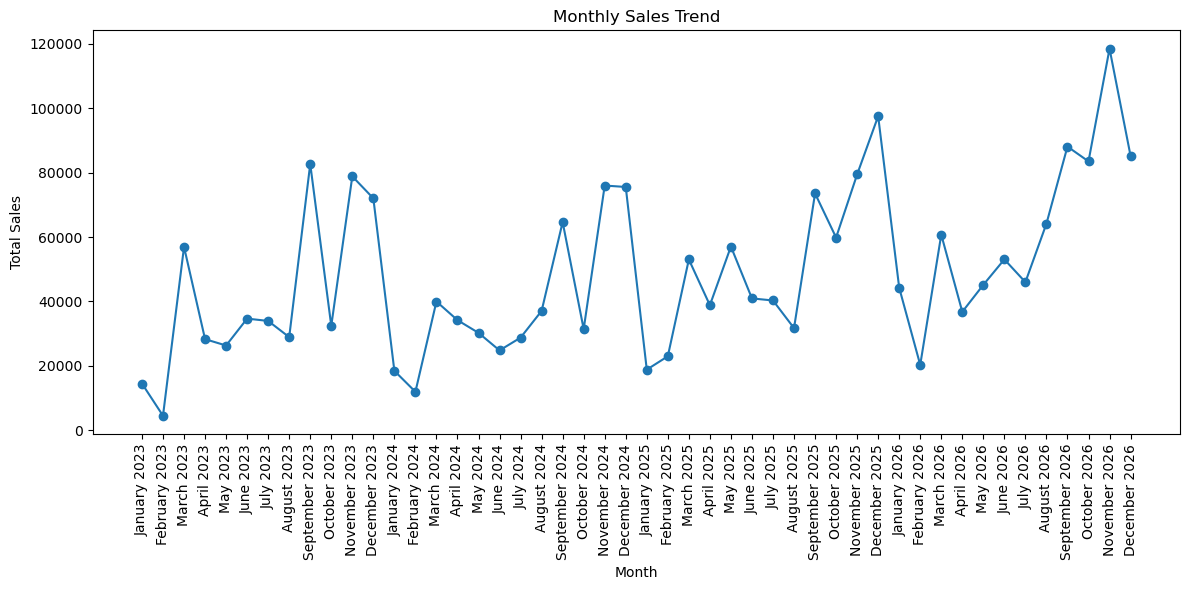

In [30]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales['Month Name'] + ' ' + monthly_sales['Year'].astype(str),
    monthly_sales['Sales'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [31]:
yearly_sales = df.groupby('Year', as_index=False)['Sales'].sum()

yearly_sales


,Year,Sales
0,2023,494040.2121
1,2024,472993.0310
2,2025,613933.5800
3,2026,745567.5312


In [32]:
yearly_profit = df.groupby('Year', as_index=False)['Profit'].sum()

yearly_profit

,Year,Profit
0,2023,51684.2957
1,2024,62020.9695
2,2025,82665.2018
3,2026,95926.3476


In [33]:
yearly_performance = df.groupby('Year', as_index=False).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
)

yearly_performance['Sales Growth %'] = (
    yearly_performance['Total_Sales'].pct_change() * 100
)

yearly_performance


,Year,Total_Sales,Total_Profit,Sales Growth %
0,2023,494040.2121,51684.2957,NaN
1,2024,472993.0310,62020.9695,-4.260216
2,2025,613933.5800,82665.2018,29.797595
3,2026,745567.5312,95926.3476,21.441074


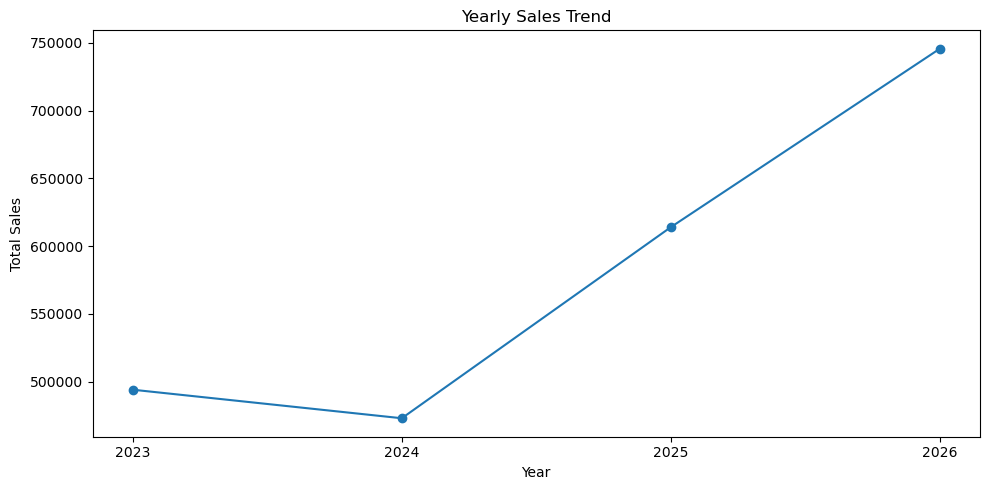

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_performance['Year'],
    yearly_performance['Total_Sales'],
    marker='o'
)

plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(yearly_performance['Year'])

plt.tight_layout()
plt.show()

In [35]:
quarterly_performance = df.groupby(
    ['Year', 'Quarter'],
    as_index=False
).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
)
quarterly_performance['Quarter Label'] = (
    quarterly_performance['Year'].astype(str)
    + '-Q'
    + quarterly_performance['Quarter'].astype(str)
)

quarterly_performance


,Year,Quarter,Total_Sales,Total_Profit,Quarter Label
0,2023,1,75971.8560,4095.1490,2023-Q1
1,2023,2,89284.5916,11684.9864,2023-Q2
2,2023,3,145535.1603,13517.3726,2023-Q3
3,2023,4,183248.6042,22386.7877,2023-Q4
4,2024,1,70391.9546,9554.6612,2024-Q1
5,2024,2,89239.4470,12200.1904,2024-Q2
6,2024,3,130449.3752,16880.3008,2024-Q3
7,2024,4,182912.2542,23385.8171,2024-Q4
8,2025,1,94840.2150,11628.4890,2025-Q1
9,2025,2,136809.1450,16594.6767,2025-Q2


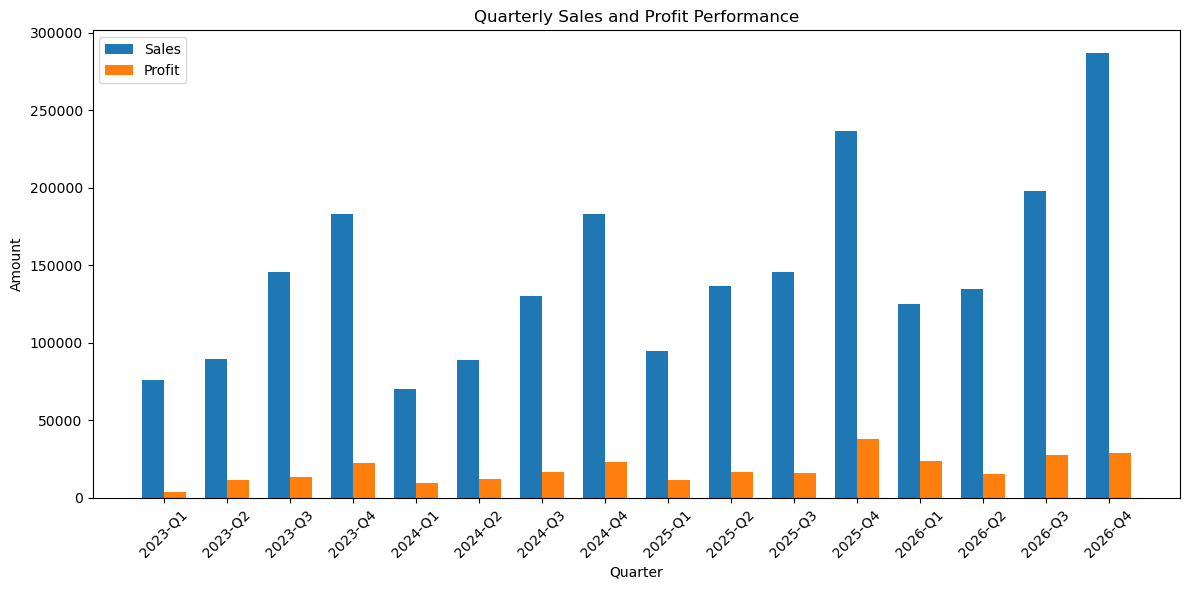

In [36]:
plt.figure(figsize=(12, 6))

x = range(len(quarterly_performance))
width = 0.35

plt.bar(
    [i - width/2 for i in x],
    quarterly_performance['Total_Sales'],
    width=width,
    label='Sales'
)

plt.bar(
    [i + width/2 for i in x],
    quarterly_performance['Total_Profit'],
    width=width,
    label='Profit'
)

plt.title('Quarterly Sales and Profit Performance')
plt.xlabel('Quarter')
plt.ylabel('Amount')
plt.xticks(x, quarterly_performance['Quarter Label'], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [37]:
product_sales = df.groupby(
    'Product Name',
    as_index=False
)['Sales'].sum()

product_sales = product_sales.sort_values(
    'Sales',
    ascending=False
)

product_sales.head(10)

,Product Name,Sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
785,HON 5400 Series Task Chairs for Big and Tall,21870.576
685,GBC DocuBind TL300 Electric Binding System,19823.479
687,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
804,Hewlett Packard LaserJet 3310 Copier,18839.686
786,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
682,GBC DocuBind P400 Electric Binding System,17965.068
812,High Speed Automatic Electric Letter Opener,17030.312


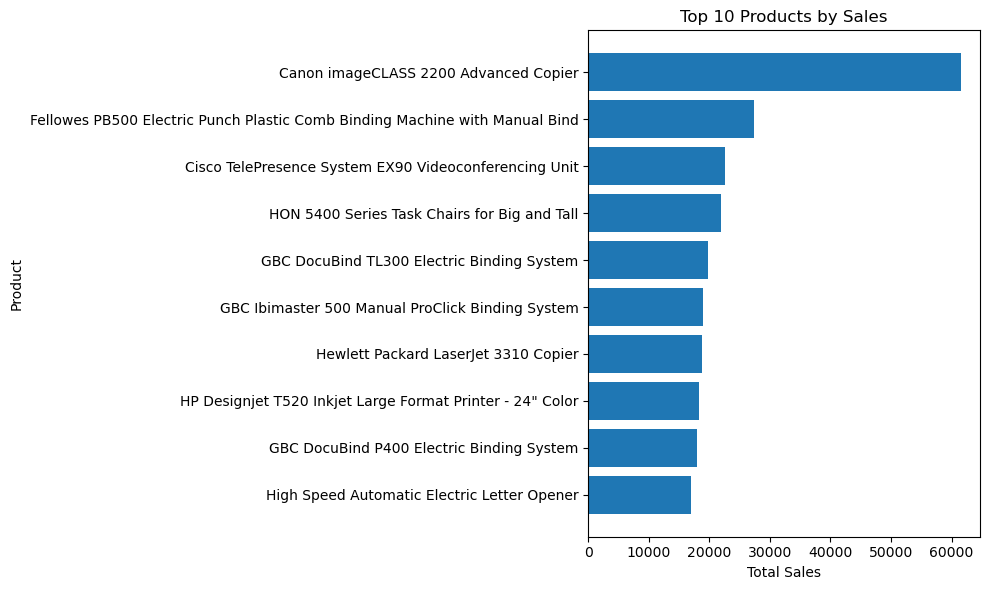

In [38]:
top_products = product_sales.head(10).sort_values('Sales')

plt.figure(figsize=(10, 6))

plt.barh(
    top_products['Product Name'],
    top_products['Sales']
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [39]:
product_profit = df.groupby(
    'Product Name',
    as_index=False
)['Profit'].sum()

product_profit = product_profit.sort_values(
    'Profit',
    ascending=False
)

product_profit.head(10)

,Product Name,Profit
404,Canon imageCLASS 2200 Advanced Copier,25199.9280
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
804,Hewlett Packard LaserJet 3310 Copier,6983.8836
400,Canon PC1060 Personal Laser Copier,4570.9347
786,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766
165,Ativa V4110MDD Micro-Cut Shredder,3772.9461
19,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
1275,Plantronics Savi W720 Multi-Device Wireless He...,3696.2820
894,Ibico EPK-21 Electric Binding System,3345.2823
1839,Zebra ZM400 Thermal Label Printer,3343.5360


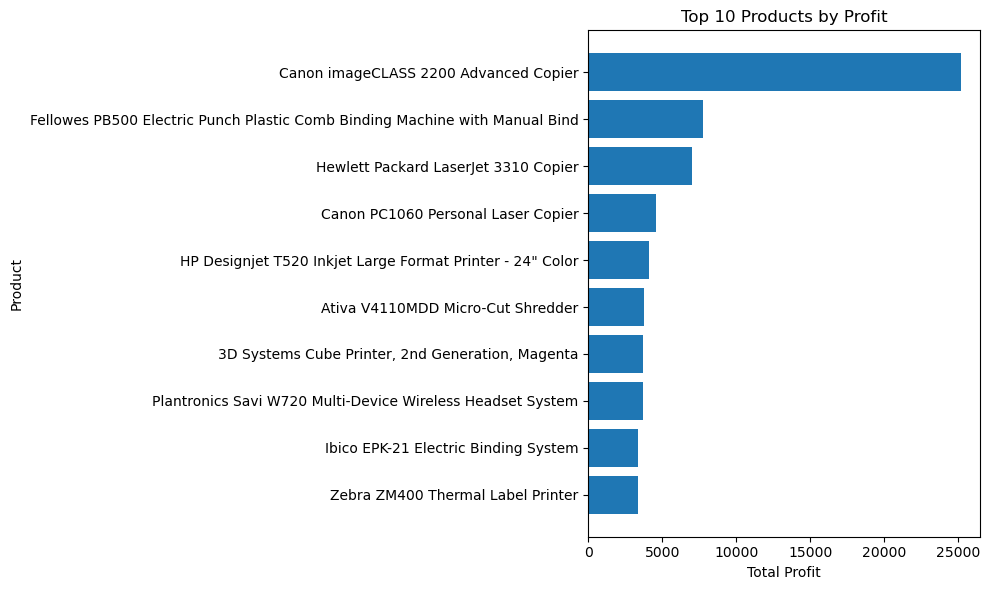

In [40]:
top_profit_products = product_profit.head(10).sort_values('Profit')

plt.figure(figsize=(10, 6))

plt.barh(
    top_profit_products['Product Name'],
    top_profit_products['Profit']
)

plt.title('Top 10 Products by Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [41]:
product_profit.sort_values('Profit').head(10)

,Product Name,Profit
475,Cubify CubeX 3D Printer Double Head Print,-8879.9704
984,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
476,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
425,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.1156
376,Bush Advantage Collection Racetrack Conference...,-1934.3976
682,GBC DocuBind P400 Electric Binding System,-1878.1662
444,Cisco TelePresence System EX90 Videoconferenci...,-1811.0784
1042,Martin Yale Chadless Opener Electric Letter Op...,-1299.1836
285,Balt Solid Wood Round Tables,-1201.0581
364,BoxOffice By Design Rectangular and Half-Moon ...,-1148.4375


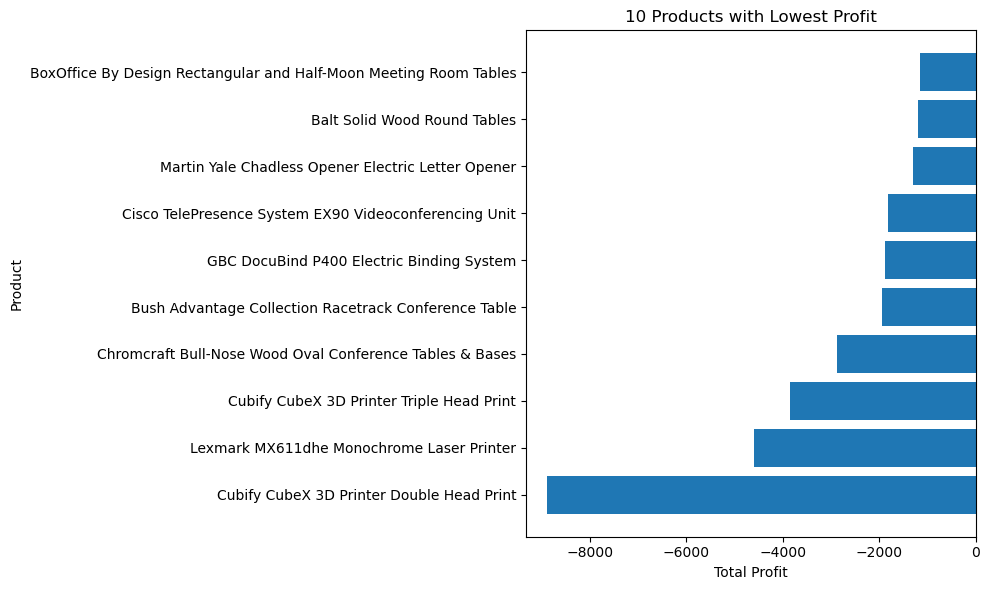

In [42]:
low_profit_products = product_profit.sort_values('Profit').head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    low_profit_products['Product Name'],
    low_profit_products['Profit']
)

plt.title('10 Products with Lowest Profit')
plt.xlabel('Total Profit')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [43]:
category_performance = df.groupby(
    'Category',
    as_index=False
).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum')
)

category_performance['Profit Margin %'] = (
    category_performance['Total_Profit'] /
    category_performance['Total_Sales']
) * 100

category_performance

,Category,Total_Sales,Total_Profit,Total_Quantity,Profit Margin %
0,Furniture,754747.7613,19729.9956,8369,2.614118
1,Office Supplies,731893.3140,126023.4434,23268,17.218827
2,Technology,839893.2790,146543.3756,7017,17.447857


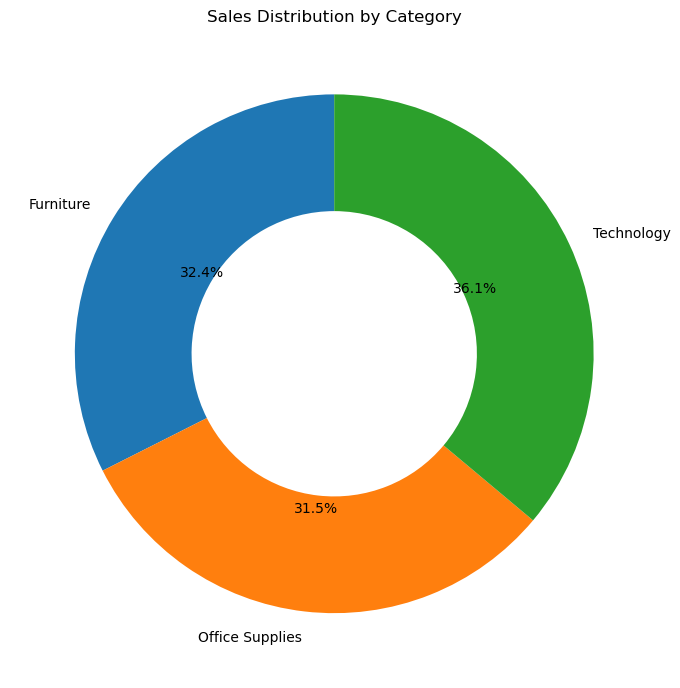

In [44]:
plt.figure(figsize=(7, 7))

plt.pie(
    category_performance['Total_Sales'],
    labels=category_performance['Category'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.45}
)

plt.title('Sales Distribution by Category')

plt.tight_layout()
plt.show()


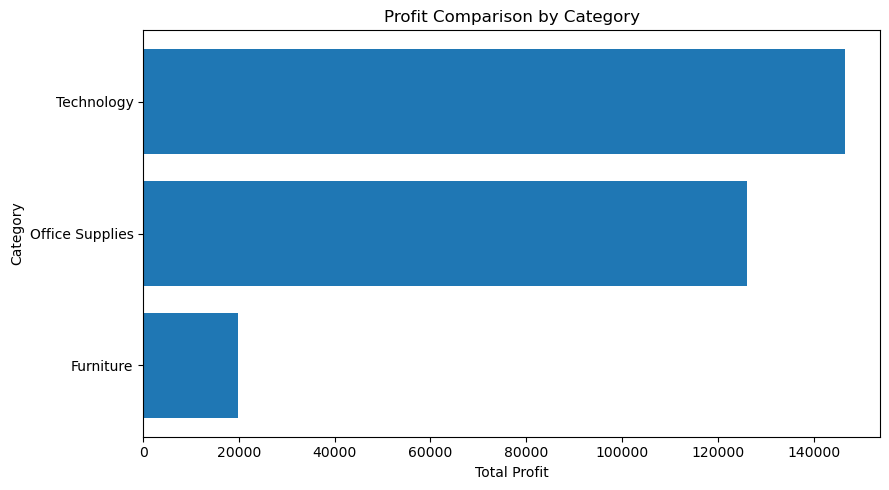

In [45]:
category_profit = category_performance.sort_values('Total_Profit')

plt.figure(figsize=(9, 5))

plt.barh(
    category_profit['Category'],
    category_profit['Total_Profit']
)

plt.title('Profit Comparison by Category')
plt.xlabel('Total Profit')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

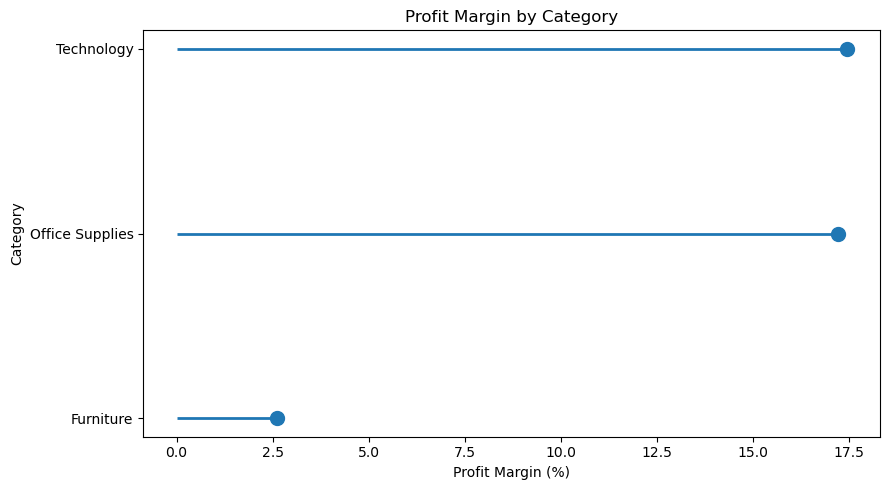

In [46]:
category_margin = category_performance.sort_values('Profit Margin %')

plt.figure(figsize=(9, 5))

plt.hlines(
    y=category_margin['Category'],
    xmin=0,
    xmax=category_margin['Profit Margin %'],
    linewidth=2
)

plt.scatter(
    category_margin['Profit Margin %'],
    category_margin['Category'],
    s=100
)

plt.title('Profit Margin by Category')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

In [47]:
region_performance = df.groupby(
    'Region',
    as_index=False
).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Orders=('Order ID', 'nunique')
)

region_performance['Profit Margin %'] = (
    region_performance['Total_Profit'] /
    region_performance['Total_Sales']
) * 100

region_performance

,Region,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit Margin %
0,Central,503170.6728,39865.3070,8820,1179,7.922820
1,East,691828.1680,94883.2603,11159,1475,13.714859
2,South,391721.9050,46749.4303,6209,822,11.934342
3,West,739813.6085,110798.8170,12466,1635,14.976585


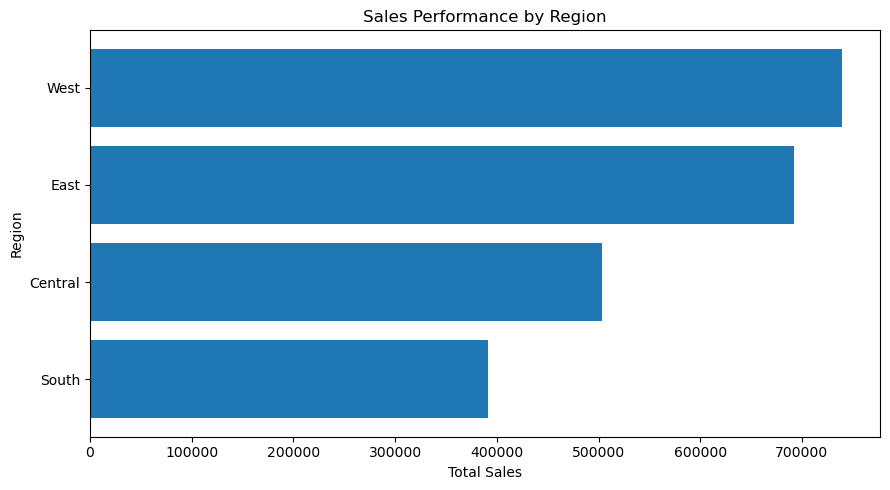

In [48]:
region_sales = region_performance.sort_values('Total_Sales')

plt.figure(figsize=(9, 5))

plt.barh(
    region_sales['Region'],
    region_sales['Total_Sales']
)

plt.title('Sales Performance by Region')
plt.xlabel('Total Sales')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

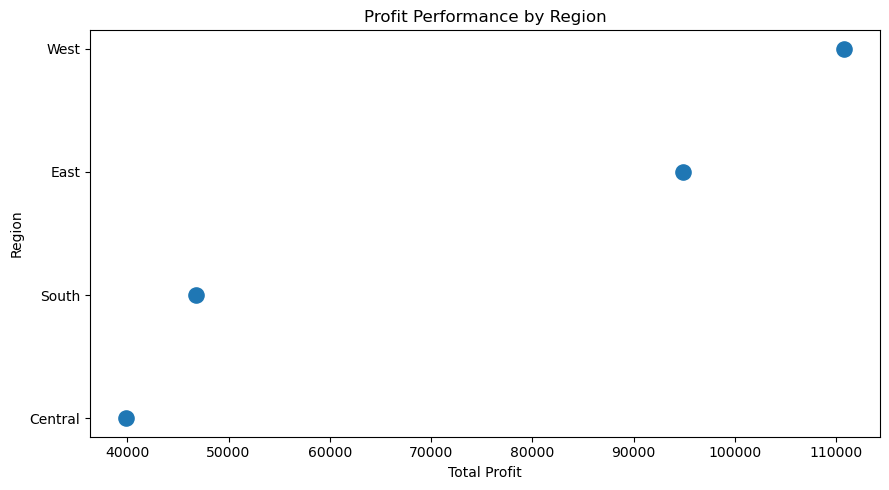

In [49]:
region_profit = region_performance.sort_values('Total_Profit')

plt.figure(figsize=(9, 5))

plt.scatter(
    region_profit['Total_Profit'],
    region_profit['Region'],
    s=120
)

plt.title('Profit Performance by Region')
plt.xlabel('Total Profit')
plt.ylabel('Region')

plt.tight_layout()
plt.show()

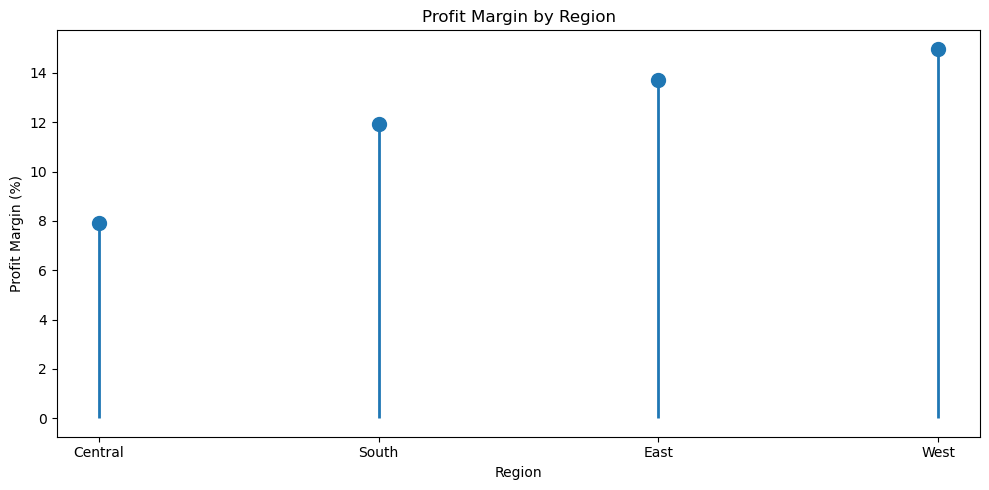

In [50]:
region_margin = region_performance.sort_values('Profit Margin %')

plt.figure(figsize=(10, 5))

plt.vlines(
    x=region_margin['Region'],
    ymin=0,
    ymax=region_margin['Profit Margin %'],
    linewidth=2
)

plt.scatter(
    region_margin['Region'],
    region_margin['Profit Margin %'],
    s=100
)

plt.title('Profit Margin by Region')
plt.xlabel('Region')
plt.ylabel('Profit Margin (%)')

plt.tight_layout()
plt.show()

In [51]:
highest_sales_region = region_performance.loc[
    region_performance['Total_Sales'].idxmax()
]

highest_sales_region

Region                    West
Total_Sales        739813.6085
Total_Profit        110798.817
Total_Quantity           12466
Total_Orders              1635
Profit Margin %      14.976585
Name: 3, dtype: object

In [52]:
highest_profit_region = region_performance.loc[
    region_performance['Total_Profit'].idxmax()
]

highest_profit_region

Region                    West
Total_Sales        739813.6085
Total_Profit        110798.817
Total_Quantity           12466
Total_Orders              1635
Profit Margin %      14.976585
Name: 3, dtype: object

In [53]:
segment_performance = df.groupby('Segment', as_index=False).agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Total_Quantity=('Quantity','sum'),
    Total_Orders=('Order ID','nunique')
)

segment_performance['Profit Margin %'] = (
    segment_performance['Total_Profit'] /
    segment_performance['Total_Sales']
) * 100

segment_performance

,Segment,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit Margin %
0,Consumer,1.170660e+06,136371.4463,19844,2628,11.649110
1,Corporate,7.158061e+05,94249.6400,11898,1552,13.166923
2,Home Office,4.400684e+05,61675.7283,6912,931,14.015031


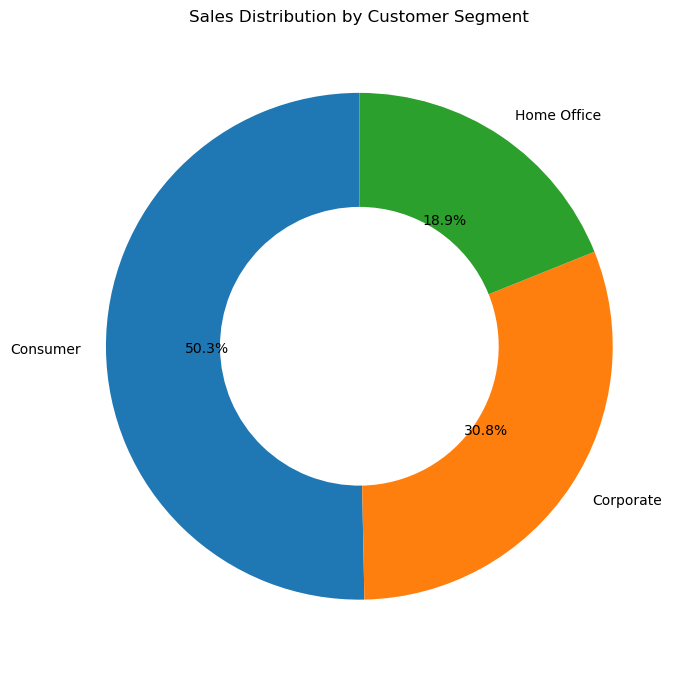

In [54]:
plt.figure(figsize=(7,7))

plt.pie(
    segment_performance['Total_Sales'],
    labels=segment_performance['Segment'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.45}
)

plt.title('Sales Distribution by Customer Segment')
plt.tight_layout()
plt.show()

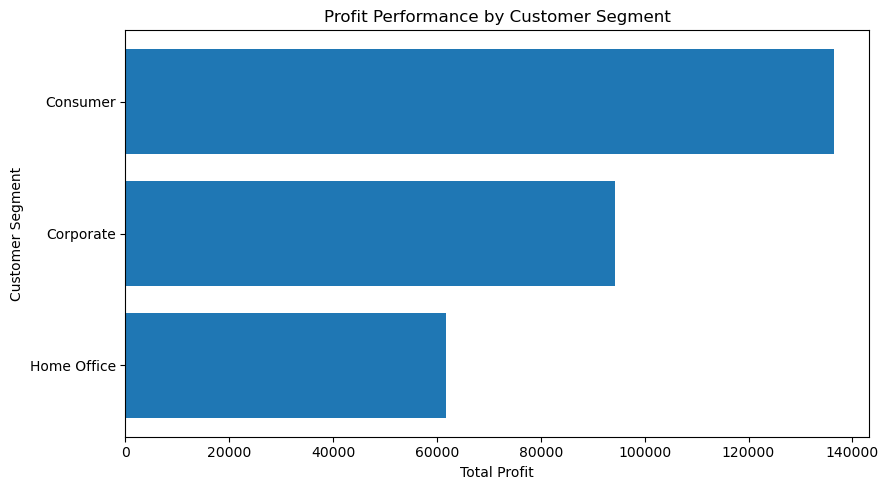

In [55]:
segment_profit = segment_performance.sort_values('Total_Profit')

plt.figure(figsize=(9,5))

plt.barh(
    segment_profit['Segment'],
    segment_profit['Total_Profit']
)

plt.title('Profit Performance by Customer Segment')
plt.xlabel('Total Profit')
plt.ylabel('Customer Segment')

plt.tight_layout()
plt.show()

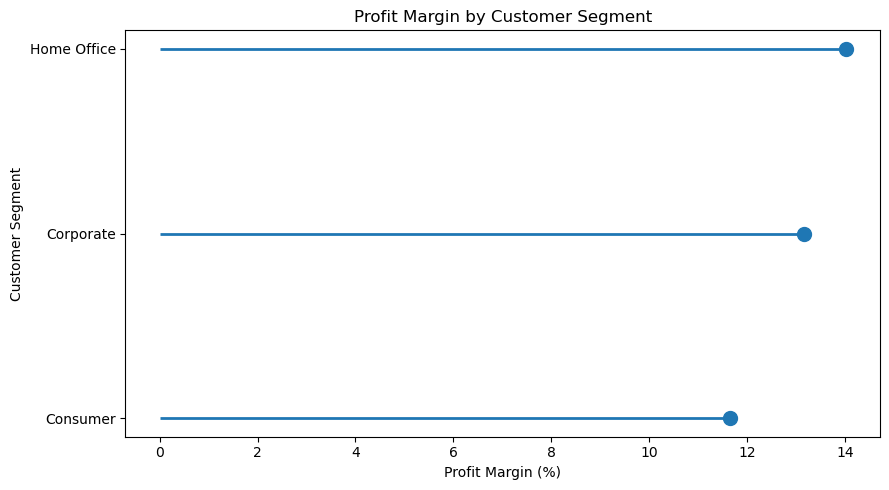

In [56]:
segment_margin = segment_performance.sort_values('Profit Margin %')

plt.figure(figsize=(9,5))

plt.hlines(
    y=segment_margin['Segment'],
    xmin=0,
    xmax=segment_margin['Profit Margin %'],
    linewidth=2
)

plt.scatter(
    segment_margin['Profit Margin %'],
    segment_margin['Segment'],
    s=100
)

plt.title('Profit Margin by Customer Segment')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Customer Segment')

plt.tight_layout()
plt.show()

In [57]:
subcategory_performance = df.groupby('Sub-Category', as_index=False).agg(
    Total_Sales=('Sales','sum'),
    Total_Profit=('Profit','sum'),
    Total_Quantity=('Quantity','sum'),
    Total_Orders=('Order ID','nunique')
)

subcategory_performance['Profit Margin %'] = (
    subcategory_performance['Total_Profit'] /
    subcategory_performance['Total_Sales']
) * 100

subcategory_performance

,Sub-Category,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit Margin %
0,Accessories,167380.3180,41936.6357,2976,718,25.054700
1,Appliances,108213.1850,18329.4844,1750,459,16.938310
2,Art,27659.0140,6653.1962,3092,756,24.054351
3,Binders,207354.8810,31426.1003,6071,1339,15.155708
4,Bookcases,115361.2043,-3632.0736,878,228,-3.148436
5,Chairs,335768.2490,27223.5323,2431,591,8.107834
6,Copiers,150745.2900,56093.9365,242,70,37.211071
7,Envelopes,16528.3620,6988.0247,914,251,42.278991
8,Fasteners,8532.2400,2428.6358,980,226,28.464223
9,Furnishings,95598.1260,13891.7430,3799,919,14.531397


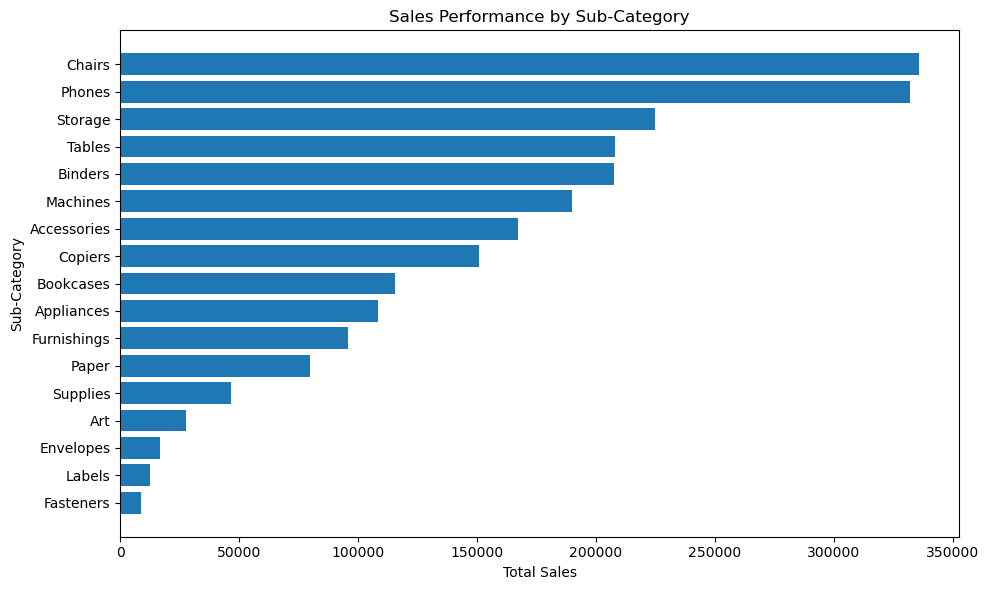

In [58]:
subcategory_sales = subcategory_performance.sort_values('Total_Sales')

plt.figure(figsize=(10,6))

plt.barh(
    subcategory_sales['Sub-Category'],
    subcategory_sales['Total_Sales']
)

plt.title('Sales Performance by Sub-Category')
plt.xlabel('Total Sales')
plt.ylabel('Sub-Category')

plt.tight_layout()
plt.show()

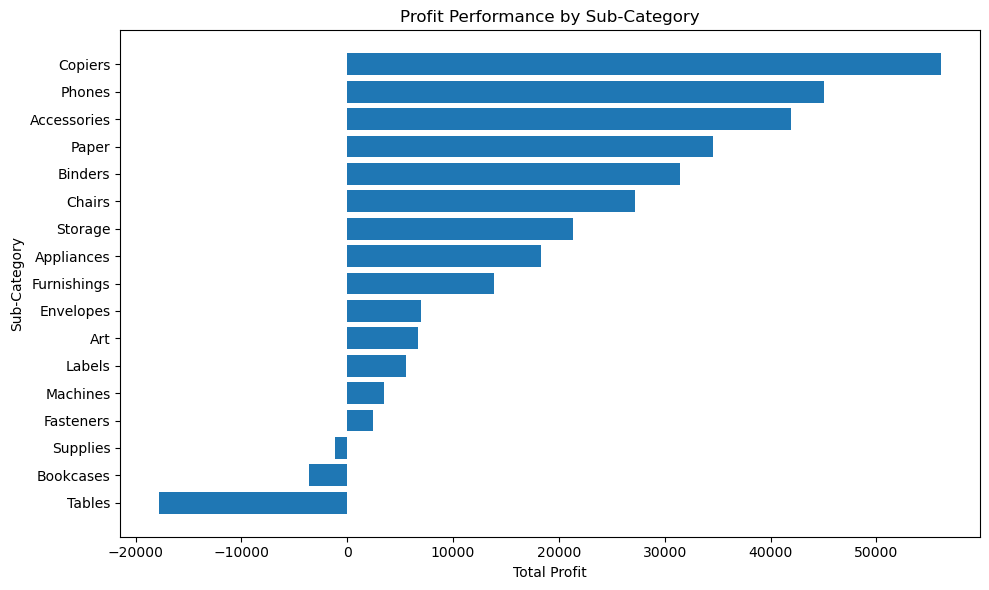

In [59]:
subcategory_profit = subcategory_performance.sort_values('Total_Profit')

plt.figure(figsize=(10,6))

plt.barh(
    subcategory_profit['Sub-Category'],
    subcategory_profit['Total_Profit']
)

plt.title('Profit Performance by Sub-Category')
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')

plt.tight_layout()
plt.show()

In [60]:
subcategory_performance.sort_values('Total_Profit').head(5)

,Sub-Category,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit Margin %
16,Tables,208020.1820,-17753.2061,1261,314,-8.534367
4,Bookcases,115361.2043,-3632.0736,878,228,-3.148436
15,Supplies,46725.4980,-1171.3945,653,189,-2.506971
8,Fasteners,8532.2400,2428.6358,980,226,28.464223
11,Machines,189925.0310,3461.9769,442,114,1.822812


In [61]:
category_yearly = df.groupby(
    ['Year', 'Category'],
    as_index=False
).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
)

category_yearly

,Year,Category,Total_Sales,Total_Profit
0,2023,Furniture,162124.8091,5884.5669
1,2023,Office Supplies,154013.9700,23489.3263
2,2023,Technology,177901.4330,22310.4025
3,2024,Furniture,172330.2970,3279.9667
4,2024,Office Supplies,137670.2150,25177.8758
5,2024,Technology,162992.5190,33563.1270
6,2025,Furniture,200979.7260,7216.2227
7,2025,Office Supplies,186373.6940,35613.2171
8,2025,Technology,226580.1600,39835.7620
9,2026,Furniture,219312.9292,3349.2393


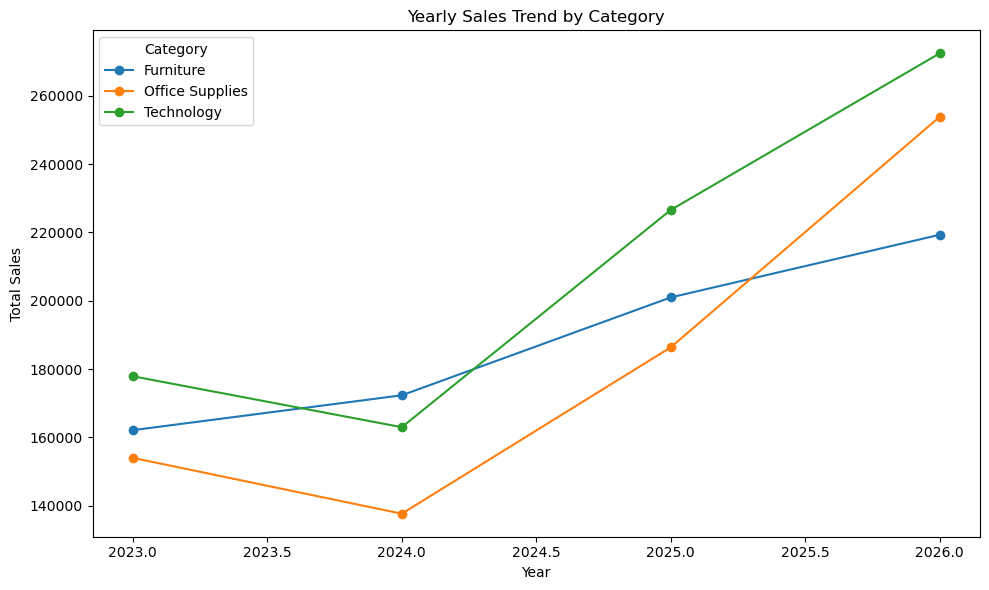

In [62]:
sales_pivot = category_yearly.pivot(
    index='Year',
    columns='Category',
    values='Total_Sales'
)

sales_pivot.plot(
    kind='line',
    marker='o',
    figsize=(10,6)
)

plt.title('Yearly Sales Trend by Category')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

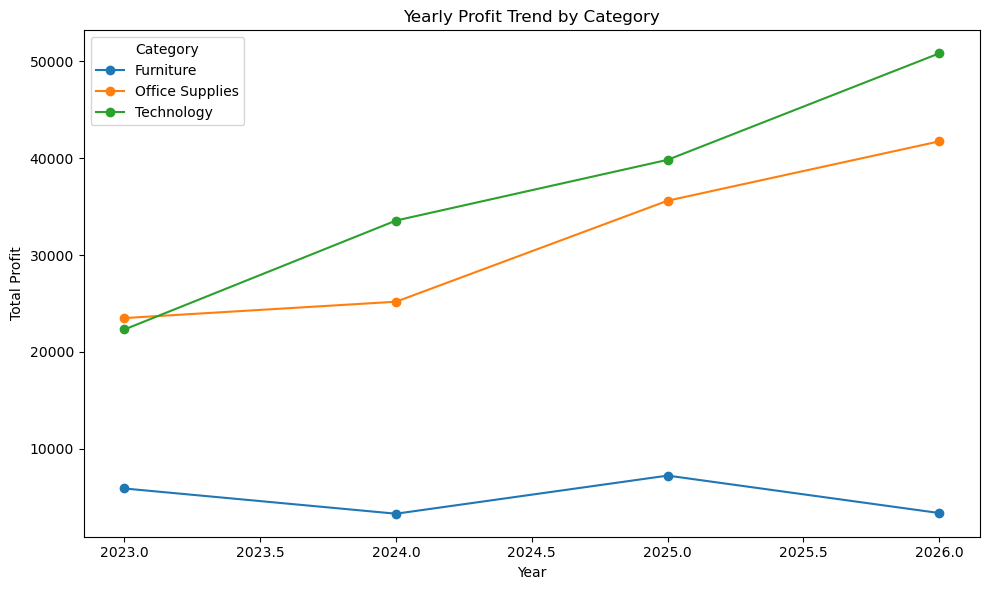

In [63]:
profit_pivot = category_yearly.pivot(
    index='Year',
    columns='Category',
    values='Total_Profit'
)

profit_pivot.plot(
    kind='line',
    marker='o',
    figsize=(10,6)
)

plt.title('Yearly Profit Trend by Category')
plt.xlabel('Year')
plt.ylabel('Total Profit')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

In [64]:
discount_performance = df.groupby('Discount', as_index=False).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum')
)

discount_performance

,Discount,Total_Sales,Total_Profit,Total_Quantity
0,0.00,1.105324e+06,326718.5872,18770
1,0.10,5.495250e+04,9099.9700,377
2,0.15,2.755852e+04,1418.9915,198
3,0.20,7.739394e+05,91079.9517,13856
4,0.30,1.044741e+05,-10513.4456,855
5,0.32,1.449346e+04,-2391.1377,105
6,0.40,1.164978e+05,-23086.3742,789
7,0.45,5.484974e+03,-2493.1111,45
8,0.50,5.891854e+04,-20506.4281,241
9,0.60,7.105940e+03,-6164.3472,554


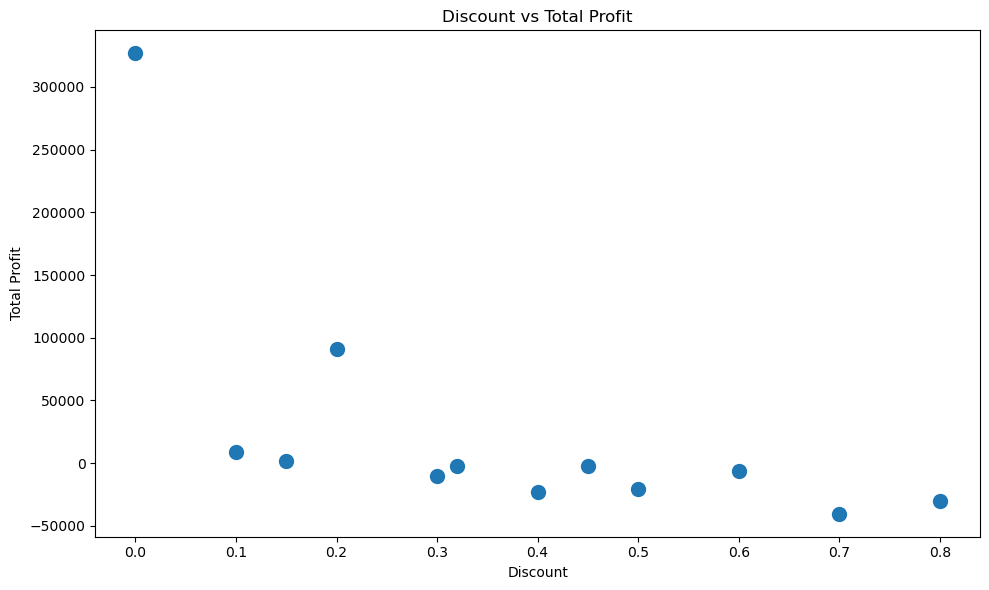

In [65]:
plt.figure(figsize=(10,6))

plt.scatter(
    discount_performance['Discount'],
    discount_performance['Total_Profit'],
    s=100
)

plt.title('Discount vs Total Profit')
plt.xlabel('Discount')
plt.ylabel('Total Profit')

plt.tight_layout()
plt.show()

In [66]:
df[['Discount', 'Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.218882
Profit,-0.218882,1.000000


In [67]:
quantity_performance = df.groupby(
    'Quantity', as_index=False
).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
)

quantity_performance

,Quantity,Total_Sales,Total_Profit
0,1,55477.0705,7784.2896
1,2,294356.4678,39419.8532
2,3,424587.8447,57495.8890
3,4,334265.1444,46293.4976
4,5,416989.8365,49669.5585
5,6,207807.3294,10568.2474
6,7,241906.2919,35172.7534
7,8,120704.4780,11244.0092
8,9,129369.2301,17795.8458
9,10,24894.6640,2278.7970


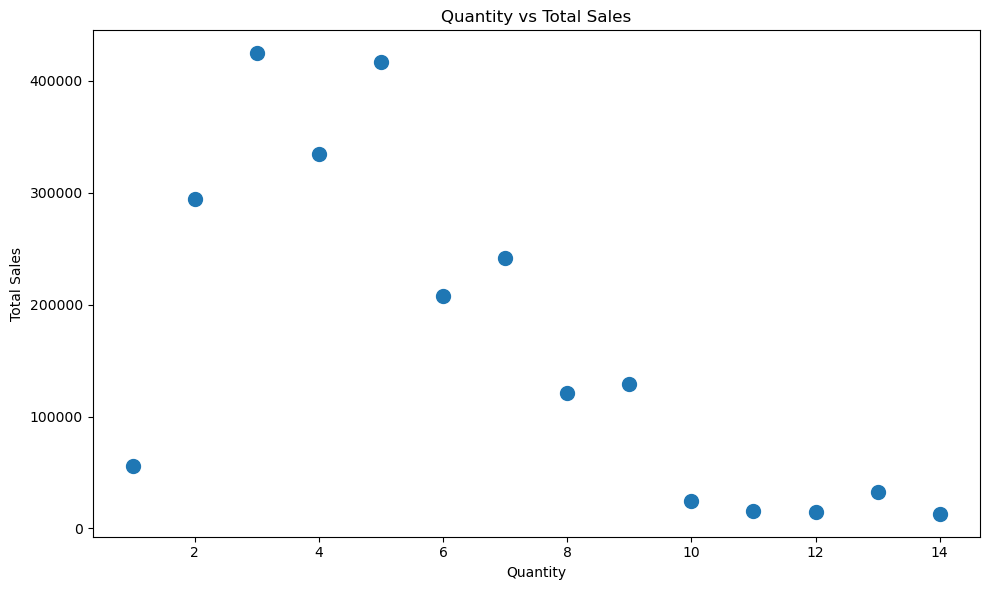

In [68]:
plt.figure(figsize=(10,6))

plt.scatter(
    quantity_performance['Quantity'],
    quantity_performance['Total_Sales'],
    s=100
)

plt.title('Quantity vs Total Sales')
plt.xlabel('Quantity')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

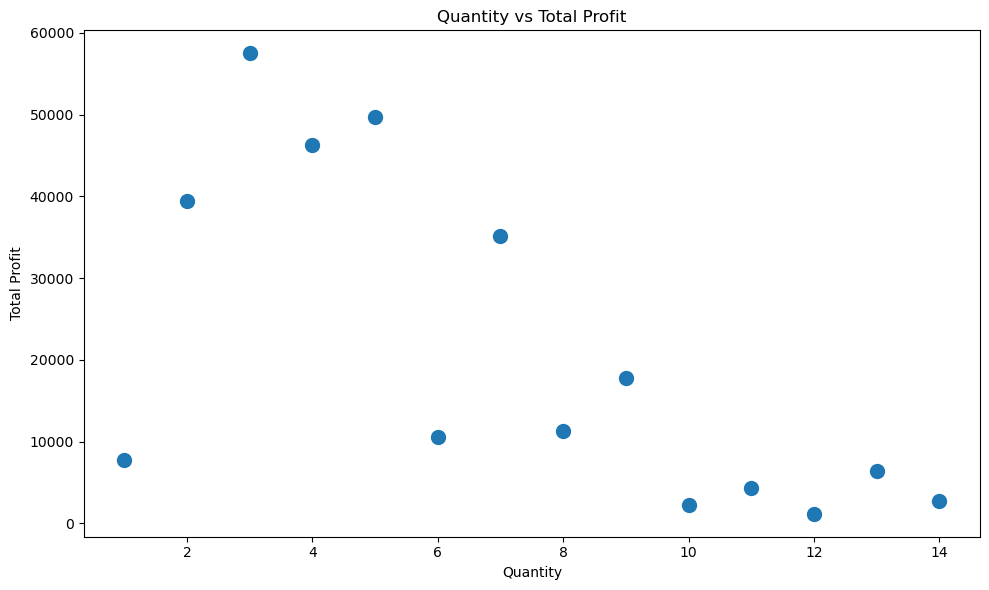

In [69]:
plt.figure(figsize=(10,6))

plt.scatter(
    quantity_performance['Quantity'],
    quantity_performance['Total_Profit'],
    s=100
)

plt.title('Quantity vs Total Profit')
plt.xlabel('Quantity')
plt.ylabel('Total Profit')

plt.tight_layout()
plt.show()

In [70]:
df[['Quantity', 'Sales', 'Profit']].corr()

,Quantity,Sales,Profit
Quantity,1.000000,0.198457,0.066145
Sales,0.198457,1.000000,0.481460
Profit,0.066145,0.481460,1.000000


In [71]:
customer_performance = df.groupby(
    'Customer Name', as_index=False
).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Orders=('Order ID', 'nunique')
)

customer_performance['Profit Margin %'] = (
    customer_performance['Total_Profit'] /
    customer_performance['Total_Sales']
) * 100

customer_performance

,Customer Name,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Profit Margin %
0,Aaron Bergman,886.156,129.3465,13,3,14.596358
1,Aaron Hawkins,1744.700,365.2152,54,7,20.932837
2,Aaron Smayling,3050.692,-253.5746,48,7,-8.312035
3,Adam Bellavance,7755.620,2054.5885,56,8,26.491609
4,Adam Hart,3250.337,281.1890,75,10,8.651072
...,...,...,...,...,...,...
795,Xylona Preis,2503.156,675.9584,121,13,27.004246
796,Yana Sorensen,6720.444,1778.2923,58,8,26.460935
797,Yoseph Carroll,5454.350,1305.6290,31,5,23.937389
798,Zuschuss Carroll,8025.707,-1032.1490,105,13,-12.860537


In [72]:
top_customers_sales = top_customers_sales.sort_values('Total_Sales')

plt.figure(figsize=(10,6))

plt.barh(
    top_customers_sales['Customer Name'],
    top_customers_sales['Total_Sales']
)

plt.title('Top 10 Customers by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Customer')

plt.tight_layout()
plt.show()

NameError: name 'top_customers_sales' is not defined

In [ ]:
ship_mode_performance = df.groupby(
    'Ship Mode', as_index=False
).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Orders=('Order ID', 'nunique')
)

ship_mode_performance['Profit Margin %'] = (
    ship_mode_performance['Total_Profit'] /
    ship_mode_performance['Total_Sales']
) * 100

ship_mode_performance

In [ ]:
plt.figure(figsize=(9,5))

plt.bar(
    ship_mode_performance['Ship Mode'],
    ship_mode_performance['Total_Sales']
)

plt.title('Sales Performance by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

In [ ]:
ship_profit = ship_mode_performance.sort_values('Total_Profit')

plt.figure(figsize=(9,5))

plt.barh(
    ship_profit['Ship Mode'],
    ship_profit['Total_Profit']
)

plt.title('Profit Performance by Ship Mode')
plt.xlabel('Total Profit')
plt.ylabel('Ship Mode')

plt.tight_layout()
plt.show()

In [73]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Sales',
        'Total Profit',
        'Total Orders',
        'Total Quantity Sold',
        'Overall Profit Margin'
    ],
    'Value': [
        df['Sales'].sum(),
        df['Profit'].sum(),
        df['Order ID'].nunique(),
        df['Quantity'].sum(),
        (df['Profit'].sum() / df['Sales'].sum()) * 100
    ]
})

kpi_summary

,KPI,Value
0,Total Sales,2.326534e+06
1,Total Profit,2.922968e+05
2,Total Orders,5.111000e+03
3,Total Quantity Sold,3.865400e+04
4,Overall Profit Margin,1.256361e+01


In [74]:
highest_sales_product = product_sales.iloc[0]
lowest_profit_product = product_profit.iloc[0]

print("Highest Sales Product:")
print(highest_sales_product)

print("\nLowest Profit Product:")
print(lowest_profit_product)

Highest Sales Product:
Product Name    Canon imageCLASS 2200 Advanced Copier
Sales                                       61599.824
Name: 404, dtype: object

Lowest Profit Product:
Product Name    Canon imageCLASS 2200 Advanced Copier
Profit                                      25199.928
Name: 404, dtype: object


In [75]:
best_sales_year = yearly_performance.loc[
    yearly_performance['Total_Sales'].idxmax()
]

best_profit_year = yearly_performance.loc[
    yearly_performance['Total_Profit'].idxmax()
]

print("Highest Sales Year:")
print(best_sales_year)

print("\nHighest Profit Year:")
print(best_profit_year)

Highest Sales Year:
Year                2026.000000
Total_Sales       745567.531200
Total_Profit       95926.347600
Sales Growth %        21.441074
Name: 3, dtype: float64

Highest Profit Year:
Year                2026.000000
Total_Sales       745567.531200
Total_Profit       95926.347600
Sales Growth %        21.441074
Name: 3, dtype: float64


In [76]:
category_performance.loc[
    category_performance['Total_Sales'].idxmax()
]

Category            Technology
Total_Sales         839893.279
Total_Profit       146543.3756
Total_Quantity            7017
Profit Margin %      17.447857
Name: 2, dtype: object

In [77]:
region_performance.loc[
    region_performance['Total_Sales'].idxmax()
]

Region                    West
Total_Sales        739813.6085
Total_Profit        110798.817
Total_Quantity           12466
Total_Orders              1635
Profit Margin %      14.976585
Name: 3, dtype: object

In [78]:
region_performance.loc[
    region_performance['Total_Profit'].idxmax()
]

Region                    West
Total_Sales        739813.6085
Total_Profit        110798.817
Total_Quantity           12466
Total_Orders              1635
Profit Margin %      14.976585
Name: 3, dtype: object

In [79]:
category_performance.loc[
    category_performance['Total_Profit'].idxmax()
]

Category            Technology
Total_Sales         839893.279
Total_Profit       146543.3756
Total_Quantity            7017
Profit Margin %      17.447857
Name: 2, dtype: object